In [11]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv' ))
    print('Thursday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')

data.head()

Something went wrong HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDataset (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x345631950>: Failed to resolve 'api.kaggle.com' ([Errno 8] nodename nor servname provided, or not known)"))


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,0
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,0
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,0
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,0
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,0


In [12]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

X = data.drop('Label', axis=1)
y = data['Label']

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train.values)
y_test_t = torch.LongTensor(y_test.values)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.layers(x)
    

input_size = X_train_t.shape[1]
num_classes = len(y.unique())
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model.to(device)

for epoch in range(10):
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 Loss: {loss.item():.4f}')


    model.eval()
    with torch.no_grad():
        X_test_device = X_test_t.to(device)
        y_pred = model(X_test_device).argmax(dim=1).cpu().numpy()

    print(classification_report(y_test, y_pred))

Epoch 1/10 Loss: 0.0002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       1.00      0.20      0.33        10

    accuracy                           1.00     57679
   macro avg       1.00      0.60      0.67     57679
weighted avg       1.00      1.00      1.00     57679

Epoch 2/10 Loss: 0.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       1.00      0.30      0.46        10

    accuracy                           1.00     57679
   macro avg       1.00      0.65      0.73     57679
weighted avg       1.00      1.00      1.00     57679

Epoch 3/10 Loss: 0.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       1.00      0.40      0.57        10

    accuracy                           1.00     57679
   macro avg       1.00      0.70      0.79     57679
we

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 5/10 Loss: 0.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       0.75      0.30      0.43        10

    accuracy                           1.00     57679
   macro avg       0.87      0.65      0.71     57679
weighted avg       1.00      1.00      1.00     57679

Epoch 6/10 Loss: 0.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       0.67      0.20      0.31        10

    accuracy                           1.00     57679
   macro avg       0.83      0.60      0.65     57679
weighted avg       1.00      1.00      1.00     57679

Epoch 7/10 Loss: 0.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       1.00      0.20      0.33        10

    accuracy                           1.00     57679
   macro avg       1.00      0.60      0.67     57679
we

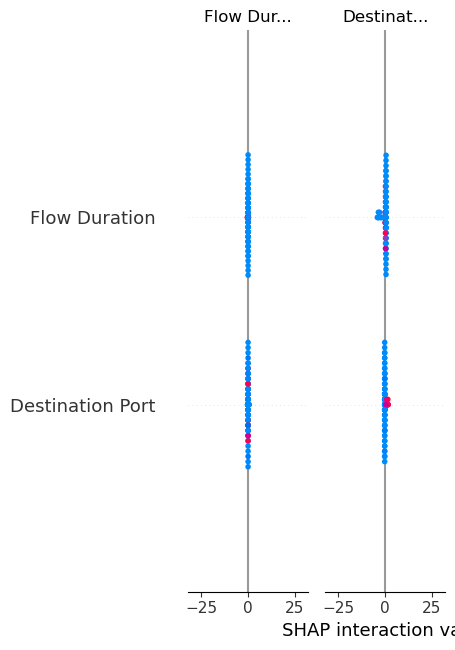

In [14]:
import matplotlib.pyplot as plt
import shap

#  Use '.to('cpu')' to return the data from the (Apple Silicon) GPU back to the CPU
model.to('cpu')
X_train_cpu = X_train_t[:100].to("cpu")
X_test_cpu = X_test_t[:100].to('cpu')
explainer = shap.DeepExplainer(model, X_train_cpu)
shap_values = explainer.shap_values(X_test_cpu)
shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns, class_names=le.classes_, show=False)
plt.tight_layout()
plt.show()